### PSMNIST with LMU

In [1]:
from __future__ import annotations
from typing import Dict, Any

import torch
import os
from pathlib import Path

from psmnist_task import PSMNISTTask
from src.train_utils.trainer import Trainer

CUDA extension for structured kernels (Cauchy and Vandermonde multiplication) not found. Install by going to extensions/kernels/ and running `python setup.py install`, for improved speed and memory efficiency. Note that the kernel changed for state-spaces 4.0 and must be recompiled.
Falling back on slow Cauchy and Vandermonde kernel. Install at least one of pykeops or the CUDA extension for better speed and memory efficiency.


### Configuration
We define a set of hyperparameters and configurations for the training process.
This includes data paths, batch sizes, learning rates, and model-specific parameters.
Using unified block factory from src.utils.block_factory for consistent configuration.

In [2]:
from src.utils.block_factory import make_lmu_block_cfg_ctor

In [3]:
current_dir = Path.cwd()
project_root = current_dir.parent.parent.parent
data_root = str(project_root / "src" / "datasets" / "psmnist" / "data")

args: Dict[str, Any] = {
    "data_root": data_root,
    "batch": 128,
    "data_loader_kwargs": {
        "num_workers": 0,
        "permutation_seed": 42,
        "normalize": "standard",
        "pin_memory": False,
        "persistent_workers": False,
    },

    "epochs": 50,
    "lr": 1e-3,
    "wd": 1e-4,
    "amp": False,
    "save_dir": "./runs/psmnist_lmu_task",
    "warmup_epochs": 5,
    "patience": 5,
    "min_delta": 0.001,
    "early_key": "accuracy",

    "d_model": 128,
    "depth": 2,
    "dropout": 0.1,
    "mlp_ratio": 2.0,
    "droppath_final": 0.0,
    "layerscale_init": 0.0,
    "residual_gain": 1.0,
    "pool": "mean",
}

args["block_cfg_ctor"] = make_lmu_block_cfg_ctor(
    dropout=args["dropout"],
    mlp_ratio=args["mlp_ratio"],
    droppath_final=args["droppath_final"],
    layerscale_init=args["layerscale_init"],
    residual_gain=args["residual_gain"],
    pool=args["pool"],
)

if torch.backends.mps.is_available():
    args["device"] = torch.device("mps")
    print("Using MPS")
elif torch.cuda.is_available():
    args["device"] = torch.device("cuda")
else:
    args["device"] = torch.device("cpu")
    args["amp"] = False

Using MPS


### Training
With the configuration set up, we can now instantiate the `PSMNISTTask` and the `Trainer`.
The `fit` method on the trainer will start the training process, which includes training,
validation, and saving the best model based on the validation accuracy.

In [4]:
from src.utils.visualization import plot_classification_history as plot_history

In [ ]:
task = PSMNISTTask()

if torch.backends.mps.is_available():
    torch.mps.set_per_process_memory_fraction(0.9)
    os.environ["PYTORCH_MPS_HIGH_WATERMARK_RATIO"] = "0.0"

trainer = Trainer(args=args, task=task)

best_metric, ckpt_path = trainer.fit()
print(f"Done. Best {trainer.early_key}={best_metric:.4f} @ {ckpt_path}")

PS-MNIST Loaders Created:
  Train: 60000 samples, 468 batches
  Test:  10000 samples, 79 batches
  Permutation seed: 42
  Sequence length: 784 (28×28)
  Classes: 10 (digits 0-9)
Loaded checkpoint from epoch 24
Val metrics: {'loss': 0.14989372519329192, 'time_s': 29.88077812499978, 'acc': 0.9624}


/Users/glbrlb/PycharmProjects/Msc/LMU_S4/.venv/lib/python3.9/site-packages/scipy/linalg/_matfuncs.py:326: RuntimeWarning: divide by zero encountered in matmul
  m, s = pick_pade_structure(Am)
/Users/glbrlb/PycharmProjects/Msc/LMU_S4/.venv/lib/python3.9/site-packages/scipy/linalg/_matfuncs.py:326: RuntimeWarning: overflow encountered in matmul
  m, s = pick_pade_structure(Am)
/Users/glbrlb/PycharmProjects/Msc/LMU_S4/.venv/lib/python3.9/site-packages/scipy/linalg/_matfuncs.py:326: RuntimeWarning: invalid value encountered in matmul
  m, s = pick_pade_structure(Am)
/Users/glbrlb/PycharmProjects/Msc/LMU_S4/.venv/lib/python3.9/site-packages/scipy/linalg/_matfuncs.py:358: RuntimeWarning: divide by zero encountered in matmul
  eAw = eAw @ eAw
/Users/glbrlb/PycharmProjects/Msc/LMU_S4/.venv/lib/python3.9/site-packages/scipy/linalg/_matfuncs.py:358: RuntimeWarning: overflow encountered in matmul
  eAw = eAw @ eAw
/Users/glbrlb/PycharmProjects/Msc/LMU_S4/.venv/lib/python3.9/site-packages/scipy/li

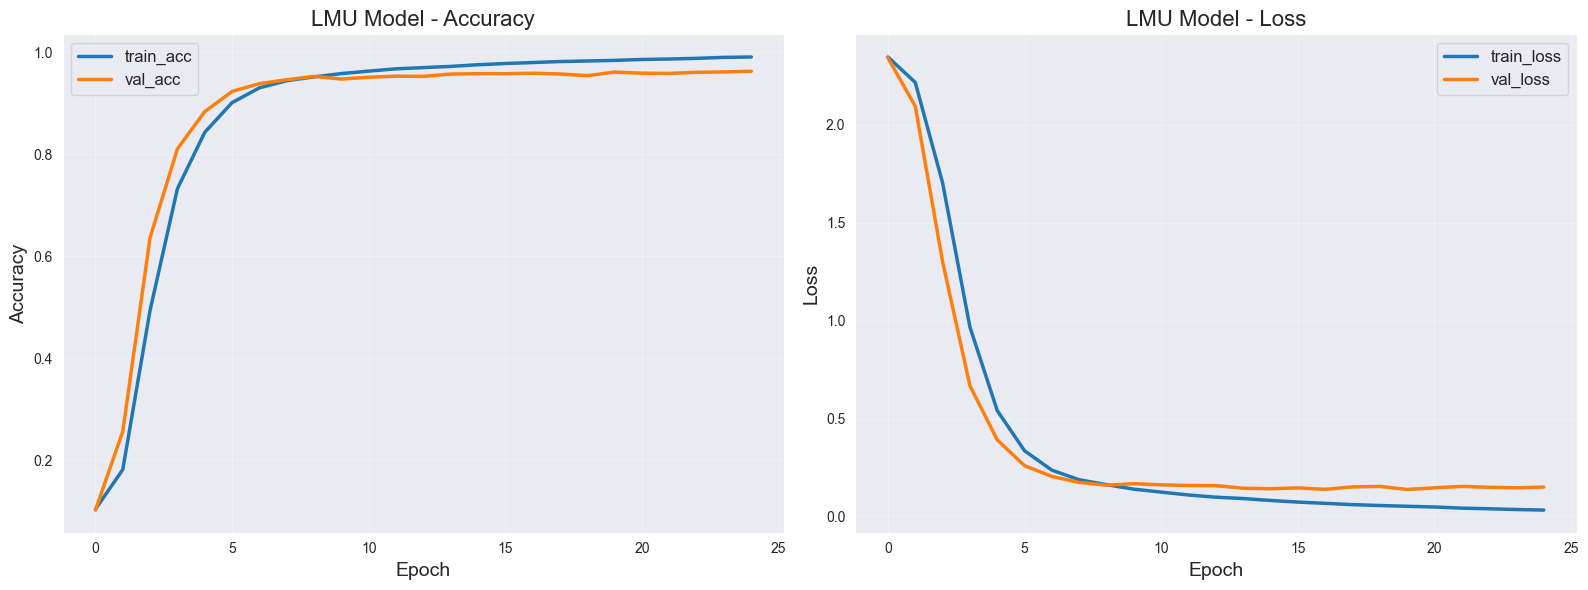

In [5]:
from src.utils.checkpoint import load_trainer_from_checkpoint

trainer = load_trainer_from_checkpoint(
    checkpoint_path=args["save_dir"] + "/best.pt",
    args=args,
    task=PSMNISTTask(),
)

history = trainer.history

plot_history(history, model_name="LMU")

In [6]:
from src.utils.common import print_model_details

print_model_details(model=trainer.model)


                            MODEL DETAILS                             

                             ARCHITECTURE                             
----------------------------------------------------------------------
Model Type: SeqClassifier
Core Layer Type: LMUCoreAdapter
Number of Blocks: 2

                              PARAMETERS                              
----------------------------------------------------------------------
Total parameters:                300,044
Trainable parameters:            300,044
Non-trainable parameters:              0
Model size (MB):                    1.14

                           MODEL ATTRIBUTES                           
----------------------------------------------------------------------

                           MODULE BREAKDOWN                           
----------------------------------------------------------------------
proj                           Linear                                256
blocks                         ModuleList

### Evaluation
After training, we can evaluate the best model on the test set.
We load the best model from the checkpoint and then run the evaluation.
The results, including accuracy, are printed.

PS-MNIST Loaders Created:
  Train: 60000 samples, 468 batches
  Test:  10000 samples, 79 batches
  Permutation seed: 42
  Sequence length: 784 (28×28)
  Classes: 10 (digits 0-9)
Loaded checkpoint from epoch 24
Val metrics: {'loss': 0.14989372519329192, 'time_s': 29.88077812499978, 'acc': 0.9624}
PS-MNIST Loaders Created:
  Train: 60000 samples, 468 batches
  Test:  10000 samples, 79 batches
  Permutation seed: 42
  Sequence length: 784 (28×28)
  Classes: 10 (digits 0-9)

✅ Test results saved to: runs/psmnist_lmu_task/test_results.json

   Test Accuracy: 0.9624 (96.24%)
   Test Loss: 0.1499

TEST SET RESULTS
Overall accuracy: 0.9624
Num classes: 10

Top-10 and Bottom-10 Classes by Performance:
Top per-class accuracies:
01. class_0                   : 0.989
02. class_1                   : 0.981
03. class_4                   : 0.974
04. class_7                   : 0.966
05. class_2                   : 0.965
06. class_8                   : 0.958
07. class_6                   : 0.951
08. cl

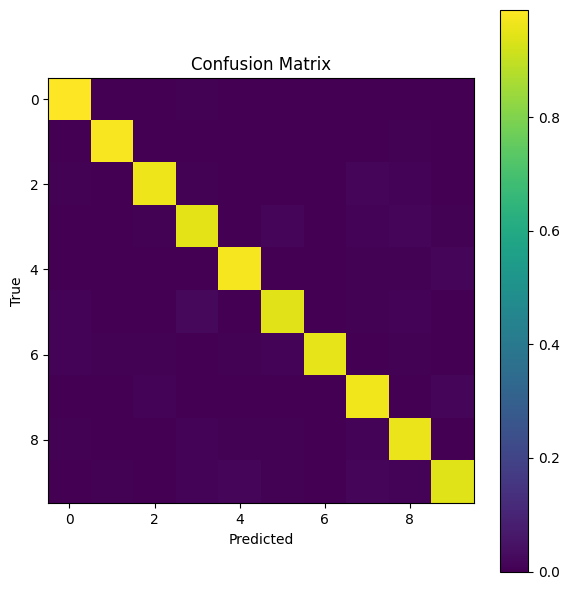

In [7]:
from src.eval.eval_utils import evaluate_classification_model as evaluate_best_model

logits_test, labels_test = evaluate_best_model(
    args=args,
    task=PSMNISTTask(),
    best_model_path=f"{args['save_dir']}/best.pt",
    num_classes=10,
    use_test_set=True,
)

### Changes in dataset length

In [ ]:
from src.eval.eval_utils import evaluate_classification_model as evaluate_best_model

if torch.backends.mps.is_available():
    torch.mps.set_per_process_memory_fraction(0.9)
    os.environ["PYTORCH_MPS_HIGH_WATERMARK_RATIO"] = "0.0"


for frac in [0.1, 0.25, 0.5]:
    print(f"\nTraining with fraction: {frac}")

    args["fraction"] = frac
    args["save_dir"] = f"./runs/psmnist_lmu_task_frac_{int(frac*100)}"
    trainer = Trainer(args=args, task=PSMNISTTask())
    best_metric, best_path = trainer.fit()

    print(f"\nTraining complete for fraction {frac}! Best validation {trainer.early_key}: {best_metric:.4f}")
    print(f"Best model saved to: {best_path}")

    history = trainer.history

    plot_history(history, model_name="LMU")

    logits_test, labels_test = evaluate_best_model(
        args=args,
        task=PSMNISTTask(),
        best_model_path=best_path,
        num_classes=10,
        use_test_set=True,
    )